# Raman spectra — example

Loads every single-spectrum `.txt` file in `data/Raman/` with `leman.loaders.RamanSpectrum` and fits each spectrum's Raman modes with `fitting.fit_raman_modes(..., material="WSe2", n_layers=...)` — one function for both layer counts, since the mode identities, seed positions, and fit tolerances live in `constants.RAMAN_MODES` rather than being hardcoded per layer count. Layer count is identified from each spectrum itself (`fitting.classify_raman_layer`), not read off the filename.

Figures are kept small (`figsize`/`dpi` tuned per plot) so several fit on screen at once — click a figure in VS Code's or JupyterLab's cell output to view it at full size. An interactive (`%matplotlib widget`/`ipympl`) backend was tried here first, but VS Code's notebook renderer could not display the resulting widget output (`Could not render content for 'application/vnd.jupyter.widget-view+json'`), so the figures below are static images.

In [1]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from leman.loaders import RamanSpectrum
from leman import constants, fitting, plotting

RAMAN_DIR = "./data/Raman"
MATERIAL = "WSe2"  # key into constants.RAMAN_MODES / constants.RAMAN_LAYER_DISCRIMINATOR

LAYER_NAMES     = constants.RAMAN_LAYER_DISCRIMINATOR[MATERIAL]["layer_names"]
BILAYER_MODES   = constants.RAMAN_MODES[MATERIAL][2]["modes"]  # peak_0, peak_1, peak_2 in that order
MONOLAYER_MODES = constants.RAMAN_MODES[MATERIAL][1]["modes"]

# Units for plotting.plot_fit_param_comparison, which has no way to know on
# its own that this fit's x-axis is a Raman shift in cm-1.
RAMAN_PARAM_LABELS = {
    "center": "Center (cm$^{-1}$)",
    "amp": "Amplitude (counts)",
    "fwhm_g": "FWHM$_G$ (cm$^{-1}$)",
    "fwhm_l": "FWHM$_L$ (cm$^{-1}$)",
}

## Load every spectrum in the folder

The folder also holds `map2.txt`, a spatial Raman map (one row per (X, Y) position, with one counts column per Raman-shift bin rather than the two-column single-spectrum shape) — a different export entirely, which `RamanSpectrum` does not read. Rather than filtering it out by filename, every `.txt` candidate is tried and anything that does not match the single-spectrum shape is skipped with the loader's own error message, so that exclusion is driven by content, not by guessing which filenames mean "map".

Everything else loads into one flat dict, regardless of layer count — filenames here happen to say `bilayer`/`monolayer`, but that is not read by anything below: which fit to run is decided from the spectrum itself (see the classification section further down), the same way it already has to be for the 2-D map, where no filename could tell you per pixel.

In [2]:
paths = sorted(glob.glob(f"{RAMAN_DIR}/*.txt"))

spectra = {}
for p in paths:
    try:
        spectrum = RamanSpectrum(p)
    except ValueError as e:
        print(f"Skipped {p}:\n  {e}\n")
        continue
    spectra[Path(p).stem] = spectrum

print(f"Loaded {len(spectra)} spectra:")
for name, s in spectra.items():
    print(s)

Skipped ./data/Raman\map2.txt:
  the number of columns changed from 1024 to 1026 at row 2; use `usecols` to select a subset and avoid this error

Loaded 6 spectra:
RamanSpectrum — 1024 points
  File  : ./data/Raman\strained_bilayer1.txt
  Shift : 36.6 – 554.7 cm⁻¹

RamanSpectrum — 1024 points
  File  : ./data/Raman\strained_bilayer2.txt
  Shift : 36.6 – 554.7 cm⁻¹

RamanSpectrum — 1024 points
  File  : ./data/Raman\strained_monolayer1.txt
  Shift : 36.6 – 554.7 cm⁻¹

RamanSpectrum — 1024 points
  File  : ./data/Raman\strained_monolayer2.txt
  Shift : 36.6 – 554.7 cm⁻¹

RamanSpectrum — 1024 points
  File  : ./data/Raman\unstrained_bilayer.txt
  Shift : 36.6 – 554.7 cm⁻¹

RamanSpectrum — 1024 points
  File  : ./data/Raman\unstrained_monolayer.txt
  Shift : 36.6 – 554.7 cm⁻¹



## Plot all spectra

Raw counts, no normalization or background subtraction — this is only checking that the loader reads every file correctly, not comparing peak shapes or intensities across samples. One panel, not split by layer count, since that split does not exist yet at this point in the notebook.

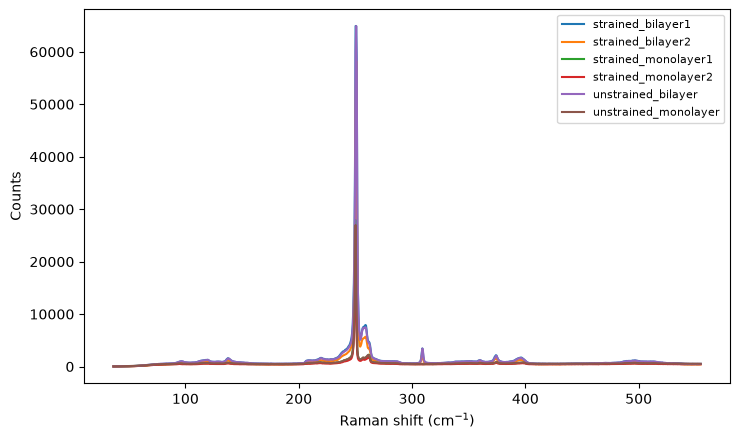

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=100)
for name, s in spectra.items():
    ax.plot(s.shift, s.counts, label=name)
ax.set_xlabel("Raman shift (cm$^{-1}$)")
ax.set_ylabel("Counts")
ax.legend(fontsize=8)
fig.tight_layout()

## Shared fitting/plotting helpers

Every spectrum is fit with the same `fitting.fit_raman_modes`, just with a different `n_layers` per spectrum (decided below, not here) — so one data-vs-fit-with-components plot and one per-parameter comparison plot cover the whole set regardless of how many modes a given spectrum turned out to have. Both are library functions now — `plotting.plot_multi_voigt_overlay` and `plotting.plot_fit_param_comparison` — promoted out of this notebook once it became clear neither has anything Raman-specific in it: both operate on any `fitting.fit_multi_voigt` result, and both already tolerate a mixed bilayer/monolayer set (`plot_multi_voigt_overlay` draws however many peaks a sample's own fit has; `plot_fit_param_comparison` leaves a gap rather than erroring when a sample lacks a given mode).

## Fit every spectrum's Raman modes — layer count identified automatically

The raw plot above shows some spectra with one dominant, narrow peak near 250 cm⁻¹ plus a smaller mode near 310 cm⁻¹, and others with the 250 cm⁻¹ peak but nothing near 310 cm⁻¹. Rather than reading that split off the filenames, `fitting.classify_raman_layer(..., material="WSe2")` checks B₂g's own height above the local baseline directly from each spectrum — the same check the 2-D map below already has to make per pixel, where no filename could possibly help. `fitting.fit_raman_modes` then fits whichever set of modes `constants.RAMAN_MODES["WSe2"]` lists for that layer count.

The 250 cm⁻¹ feature does not fully describe itself with one peak either: it has a visible shoulder on its right side that a lone symmetric-ish pseudo-Voigt leaves behind as residual, not noise. These features match modes reported for WSe₂ in Pan et al. 2022 (*"Signature of lattice dynamics in twisted 2D homo/hetero-bilayers"*, 2D Materials 9, 045018, doi:10.1088/2053-1583/ac83d4): E₂g/A₁g (≈250 cm⁻¹, nearly degenerate — which is exactly why they do not split into two resolvable peaks here), 2LA(M) (≈260 cm⁻¹, a second-order, double-resonance mode — a different scattering mechanism from the other two, which is why it is much weaker), and B₂g (≈309 cm⁻¹, present only when there is a second layer to couple to).

The recipe behind `fitting.fit_raman_modes` — fit the seeded modes first, locate 2LA(M) from that fit's own residual rather than a fixed literature-style guess (245, 253, 255, 258, 259, 260, and 261 cm⁻¹ seeds were all tried by hand against this data; only ≈259 cm⁻¹ converges cleanly and consistently), then refit everything together — is documented on that function; the per-mode seed positions and tolerances it reads live in `constants.RAMAN_MODES["WSe2"]`. That the located shoulder lands within 1 cm⁻¹ of this paper's ≈260 cm⁻¹ 2LA(M) value is a check on the method, not an input to it.

In [4]:
FIT_WINDOW = (220.0, 340.0)  # cm-1, covers all three possible features plus baseline margin

fit_results = {}
fit_windows = {}
layer_of = {}
for name, s in spectra.items():
    n_layers = fitting.classify_raman_layer(s.shift, s.counts, material=MATERIAL)
    layer_of[name] = n_layers

    mask = (s.shift >= FIT_WINDOW[0]) & (s.shift <= FIT_WINDOW[1])
    fit_windows[name] = (s.shift[mask], s.counts[mask])
    fit_results[name] = fitting.fit_raman_modes(
        s.shift, s.counts, material=MATERIAL, n_layers=n_layers, fit_window=FIT_WINDOW,
    )

for name, result in fit_results.items():
    modes = constants.RAMAN_MODES[MATERIAL][layer_of[name]]["modes"]
    print(f"{name} -- classified: {LAYER_NAMES[layer_of[name]]}")
    for i, mode in enumerate(modes):
        print(f"  {mode:>9s}: center={result.params[f'center_{i}']:.2f} cm-1  amp={result.params[f'amp_{i}']:.0f}")
    print(result)
    print()

strained_bilayer1 -- classified: bilayer
    E2g/A1g: center=250.56 cm-1  amp=68805
     2LA(M): center=258.70 cm-1  amp=6357
        B2g: center=309.11 cm-1  amp=2434
FitResult [multi_voigt+constant]  R²=0.9879
  amp_0        = 68805 ± 8e+02
  center_0     = 250.56 ± 0.01
  fwhm_g_0     = 1.1833 ± 0.11
  fwhm_l_0     = 1.3019 ± 0.11
  amp_1        = 6356.9 ± 4.6e+02
  center_1     = 258.7 ± 0.2
  fwhm_g_1     = 3.8446 ± 2.1
  fwhm_l_1     = 3.3217 ± 2.3
  amp_2        = 2434.2 ± 8.6e+02
  center_2     = 309.11 ± 0.22
  fwhm_g_2     = 0.9798 ± 1.5
  fwhm_l_2     = 0.5 ± 1.7
  offset       = 1005.6 ± 77

strained_bilayer2 -- classified: bilayer
    E2g/A1g: center=250.59 cm-1  amp=58001
     2LA(M): center=258.83 cm-1  amp=4430
        B2g: center=309.06 cm-1  amp=1685
FitResult [multi_voigt+constant]  R²=0.9931
  amp_0        = 58001 ± 5.2e+02
  center_0     = 250.59 ± 0.0067
  fwhm_g_0     = 0.55954 ± 0.13
  fwhm_l_0     = 1.5267 ± 0.077
  amp_1        = 4429.7 ± 2.6e+02
  center_1   

**This converges cleanly and consistently** — every center is well inside its bound (no pinning at a boundary), and same-mode centers land at essentially the same positions across the three samples that share a layer count (E₂g/A₁g ≈ 250.1–250.6 cm⁻¹, 2LA(M) ≈ 258.6–260.5 cm⁻¹, B₂g ≈ 309.1–309.3 cm⁻¹ where present), matching Pan et al. 2022 to within ~1 cm⁻¹. That stability, not just R², is what makes this fit trustworthy — a fit that only "works" for one sample, or only by sitting at a bound, was the signal that the model (not just the seed) was wrong, not something to average away.

As a check on the classifier itself — not an input to it, and not needed by anything above — every filename here happens to independently say `bilayer`/`monolayer`:

In [5]:
for name, n_layers in layer_of.items():
    from_filename = 2 if "bilayer" in name.lower() else 1
    assert n_layers == from_filename, (
        f"{name}: classifier says {LAYER_NAMES[n_layers]}, filename implies {LAYER_NAMES[from_filename]}"
    )
print("Classifier agrees with every filename (checked, not assumed).")

Classifier agrees with every filename (checked, not assumed).


(<Figure size 1500x800 with 6 Axes>,
 array([[<Axes: title={'center': 'strained_bilayer1'}, xlabel='Raman shift (cm$^{-1}$)', ylabel='Counts'>,
         <Axes: title={'center': 'strained_bilayer2'}, xlabel='Raman shift (cm$^{-1}$)', ylabel='Counts'>,
         <Axes: title={'center': 'strained_monolayer1'}, xlabel='Raman shift (cm$^{-1}$)', ylabel='Counts'>],
        [<Axes: title={'center': 'strained_monolayer2'}, xlabel='Raman shift (cm$^{-1}$)', ylabel='Counts'>,
         <Axes: title={'center': 'unstrained_bilayer'}, xlabel='Raman shift (cm$^{-1}$)', ylabel='Counts'>,
         <Axes: title={'center': 'unstrained_monolayer'}, xlabel='Raman shift (cm$^{-1}$)', ylabel='Counts'>]],
       dtype=object))

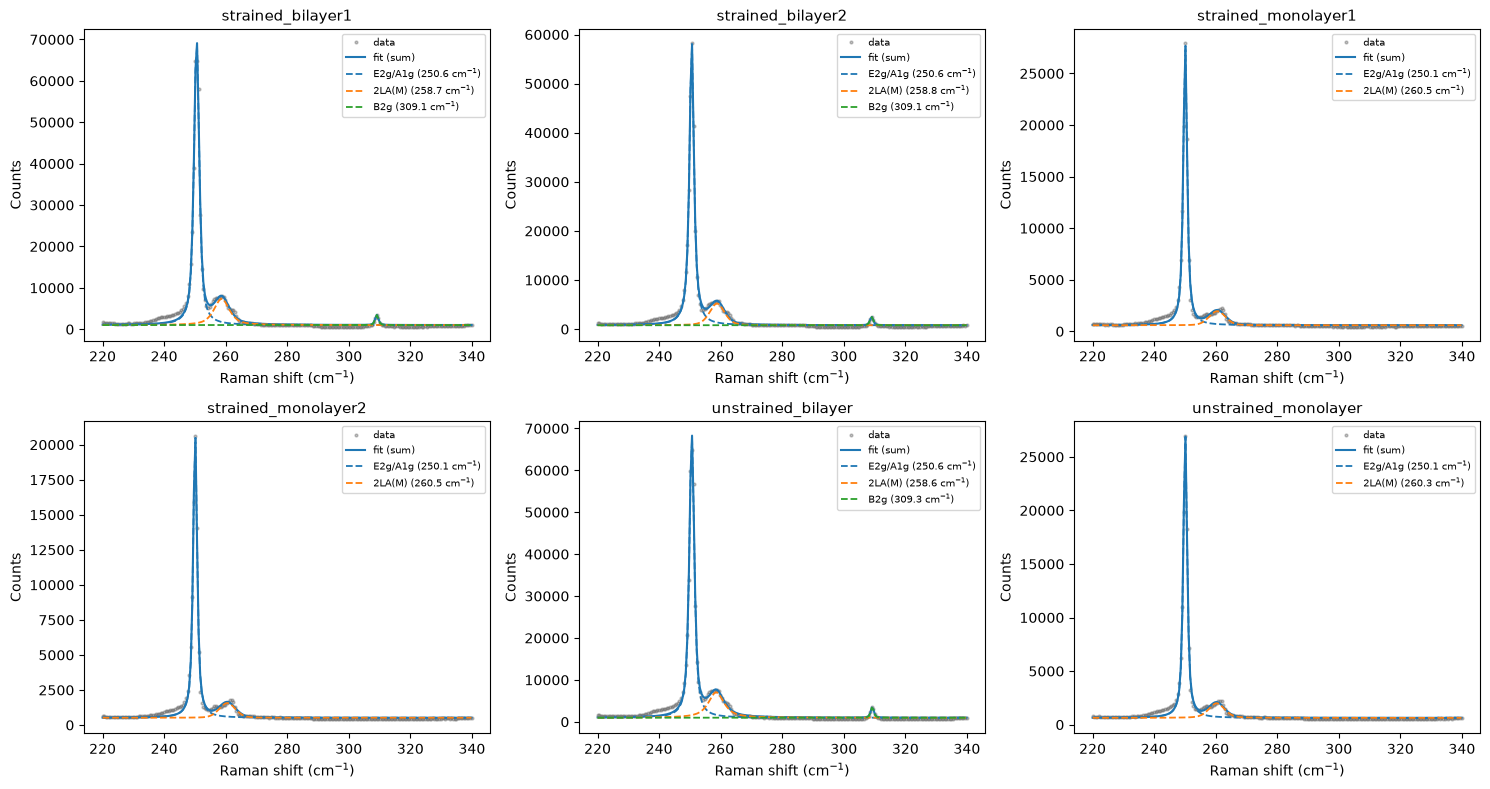

In [6]:
plotting.plot_multi_voigt_overlay(
    fit_results, fit_windows, BILAYER_MODES,
    xlabel="Raman shift (cm$^{-1}$)", ylabel="Counts", x_unit=" cm$^{-1}$",
)

## Compare the fitted parameters across all six samples

One grid figure — rows are modes, columns are fitted parameters — covering every loaded spectrum together, monolayer and bilayer alike: `BILAYER_MODES` (3 modes) is a superset of `MONOLAYER_MODES` (2), so the B₂g row simply leaves a gap at each monolayer sample's x-position rather than needing a separate call. Error bars are the 1-sigma uncertainties `fit_multi_voigt` already returns in `result.errors`, not just the point values. Each sample keeps the same color in every panel, so a color always means the same spectrum.

(<Figure size 1280x780 with 12 Axes>,
 array([[<Axes: title={'center': 'Center (cm$^{-1}$)'}, ylabel='E2g/A1g'>,
         <Axes: title={'center': 'Amplitude (counts)'}>,
         <Axes: title={'center': 'FWHM$_G$ (cm$^{-1}$)'}>,
         <Axes: title={'center': 'FWHM$_L$ (cm$^{-1}$)'}>],
        [<Axes: ylabel='2LA(M)'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='B2g'>, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

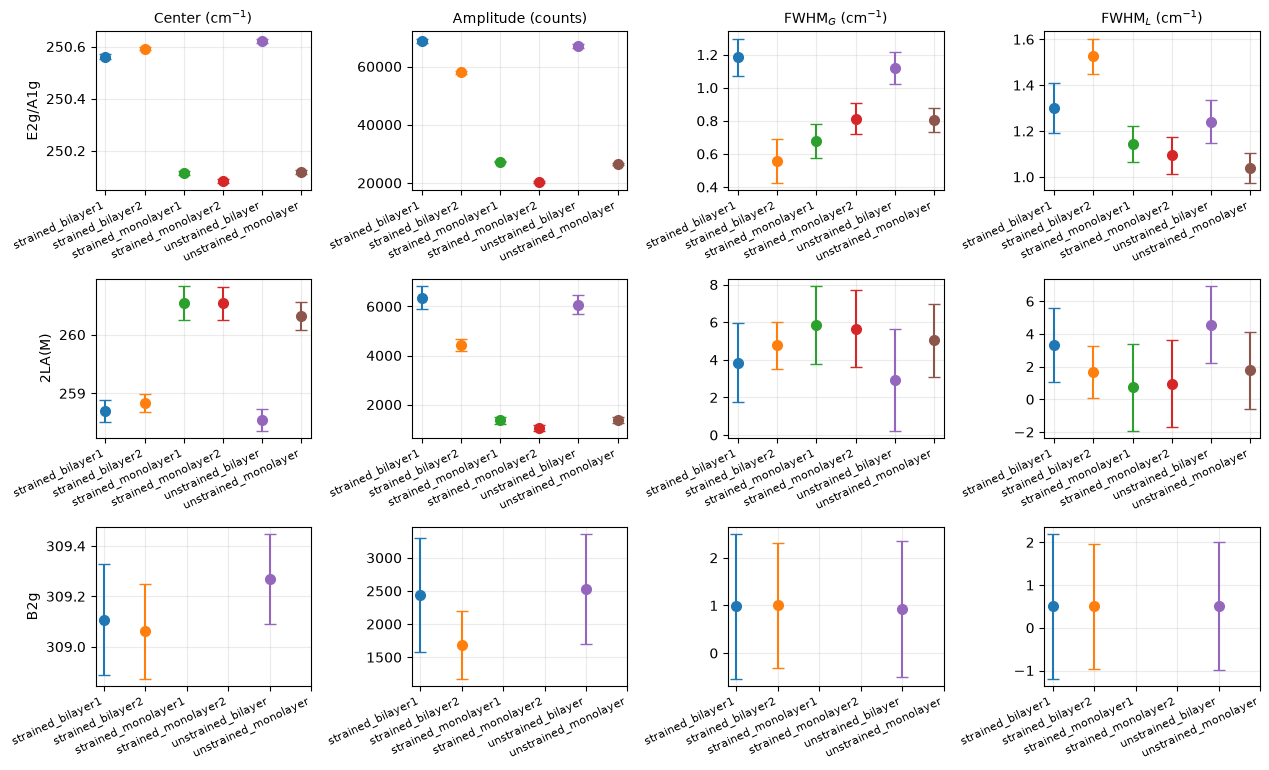

In [7]:
plotting.plot_fit_param_comparison(fit_results, BILAYER_MODES, param_labels=RAMAN_PARAM_LABELS)

## A 2-D map spanning both layer counts

`map2.txt` is a spatial Raman map, not a single spectrum: one row per (X, Y) scan position, with a full spectrum's worth of counts columns per row, plus a shared shift-axis row — a different export shape from everything above, loaded by `leman.loaders.RamanMap` rather than `RamanSpectrum` (see its docstring for the exact layout). This particular map turns out to cover **both** monolayer and bilayer regions of the flake — visible directly in the classification map below as a clean diagonal boundary, not a scattered/noisy split, which is what makes fitting each pixel with the *right* one of the two functions above meaningful rather than arbitrary.

In [8]:
from leman.loaders import RamanMap

raman_map = RamanMap(f"{RAMAN_DIR}/map2.txt")
print(raman_map)

RamanMap — 10 x 8 = 80 points
  File  : ./data/Raman/map2.txt
  X     : -10.66 – 0.11 µm
  Y     : 0.09 – 14.73 µm
  Shift : 36.6 – 554.7 cm⁻¹



### Classify and fit every pixel

Each of the 80 spectra is classified with `fitting.classify_raman_layer(..., material="WSe2")` (B₂g present or not, checked against the *local* baseline near 300–320 cm⁻¹ rather than zero, since the baseline level itself varies across the map — see `constants.RAMAN_LAYER_DISCRIMINATOR["WSe2"]`) and then fit with `fitting.fit_raman_modes(..., n_layers=<the classified count>)` — one fit call regardless of layer count now, since which modes to fit is data (`constants.RAMAN_MODES`) rather than a choice between two functions.

**This surfaced a real bug, fixed in the library rather than papered over here:** the bilayer recipe originally seeded the B₂g amplitude from the single nearest-grid-point value at its seed position. That was fine against the strong, clean reference spectra, but on map pixels near the bilayer/monolayer boundary — where B₂g is real but weak — missing the true peak by even one bin was enough that roughly a third of the bilayer pixels failed to converge (25 of 45, confirmed by first running this map through the unpatched function). The fix uses a small window's max around the seed instead of one point; every one of the 80 pixels now converges with R² ≥ 0.9.

In [9]:
n_layers_map = np.empty((raman_map.n_y, raman_map.n_x), dtype=int)
map_results  = np.empty((raman_map.n_y, raman_map.n_x), dtype=object)

for iy in range(raman_map.n_y):
    for ix in range(raman_map.n_x):
        spec = raman_map.spectrum_at(ix, iy)
        n_layers = fitting.classify_raman_layer(raman_map.shift, spec, material=MATERIAL)
        n_layers_map[iy, ix] = n_layers
        map_results[iy, ix] = fitting.fit_raman_modes(
            raman_map.shift, spec, material=MATERIAL, n_layers=n_layers,
        )

n_bilayer = int((n_layers_map == 2).sum())
n_mono = int((n_layers_map == 1).sum())
n_low_r2 = sum(
    not r.converged or r.r_squared < 0.9
    for r in map_results.ravel()
)
print(f"{n_bilayer} bilayer, {n_mono} monolayer, out of {n_layers_map.size} pixels")
print(f"{n_low_r2} pixel(s) did not converge or have R² < 0.9")

45 bilayer, 35 monolayer, out of 80 pixels
0 pixel(s) did not converge or have R² < 0.9


### Classification map

Plotted before the peak maps below because it is the thing that justifies fitting pixel-by-pixel with two different functions in the first place — a scattered, salt-and-pepper classification would mean the discriminator was picking up noise, not a real boundary.

Plotted with `plotting.plot_image`, statically — an earlier version used `plotting.plot_image_interactive`'s `ipywidgets` color-range slider, but VS Code's notebook renderer duplicated its output unpredictably (the same failure mode as the `%matplotlib widget`/`ipympl` canvas tried even earlier in this notebook), so every map below is now a plain image instead. To change a map's color limits, redraw it directly with an explicit `clim=(vmin, vmax)` — each map cell below ends with a commented-out example of exactly that call.

(<Figure size 430x360 with 2 Axes>,
 <Axes: xlabel='X ($\\mu$m)', ylabel='Y ($\\mu$m)'>,
 <matplotlib.image.AxesImage at 0x2b9c5fc6900>)

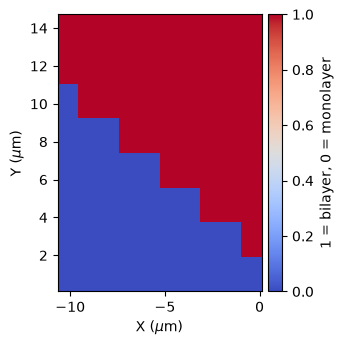

In [10]:
layer_numeric = (n_layers_map == 2).astype(float)
plotting.plot_image(
    layer_numeric,
    cmap="coolwarm",
    colorbar_label="1 = bilayer, 0 = monolayer",
    extent=(raman_map.x.min(), raman_map.x.max(), raman_map.y.min(), raman_map.y.max()),
    origin="lower", xlabel=r"X ($\mu$m)", ylabel=r"Y ($\mu$m)",
    figsize=(4.3, 3.6), dpi=100,
)

# To change this map's color limits, redraw it with an explicit clim=(vmin, vmax):
# plotting.plot_image(layer_numeric, clim=(0.0, 1.0), cmap="coolwarm",
#                      colorbar_label="1 = bilayer, 0 = monolayer",
#                      extent=(raman_map.x.min(), raman_map.x.max(), raman_map.y.min(), raman_map.y.max()),
#                      origin="lower", xlabel=r"X ($\mu$m)", ylabel=r"Y ($\mu$m)")

### Peak position and intensity maps

For each mode: **position** is that peak's fitted `center` (where its maximum sits), and **intensity** is its fitted `amp` — for a Voigt component, the amplitude parameter *is* the curve's height at its own center (verified when `fit_voigt`/`fit_multi_voigt` were first added: both line-shape terms evaluate to 1 exactly at `center`), so this is literally the peak's maximum, not a proxy for it. B₂g's maps are masked (blank) over monolayer pixels — it was never fit there, not fit and found to be zero.

All six maps are arranged in one grid (rows = modes, columns = position/intensity) via plain `plt.subplots` and `plotting.plot_image(..., ax=...)`, statically — no color-range slider (see the note on the classification map above for why). The cell ends with a commented-out call showing how to redraw any one map with an explicit `clim=(vmin, vmax)`.

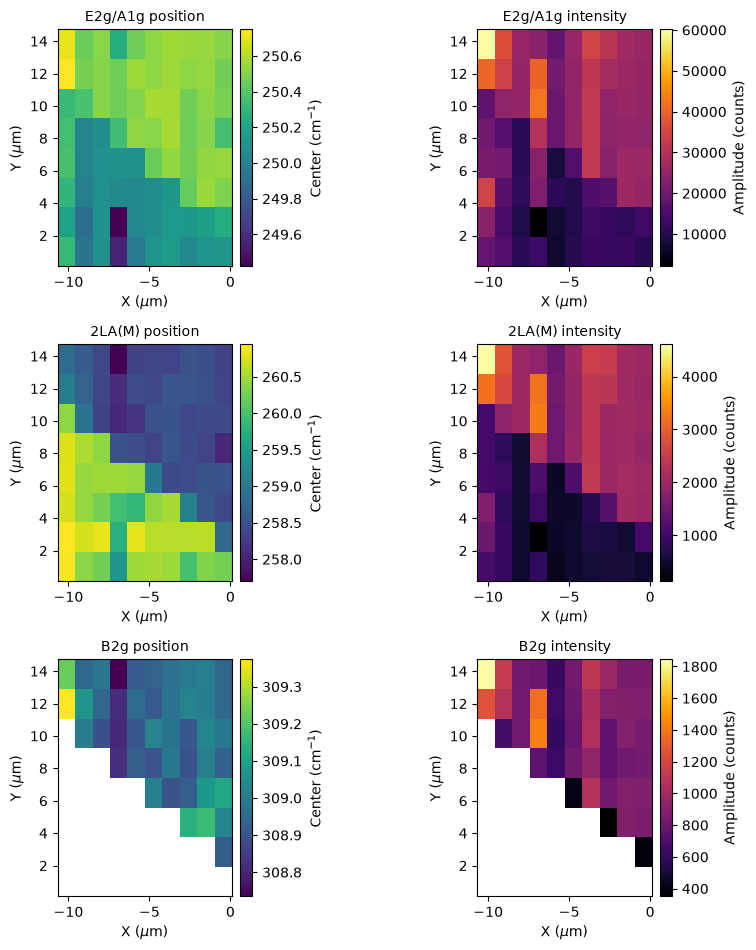

In [11]:
MAP_MODES = {mode: i for i, mode in enumerate(BILAYER_MODES)}
MAP_EXTENT = (raman_map.x.min(), raman_map.x.max(), raman_map.y.min(), raman_map.y.max())

fig, axes = plt.subplots(len(MAP_MODES), 2, figsize=(9, 3.2 * len(MAP_MODES)), dpi=100)
for row, (mode, mode_index) in enumerate(MAP_MODES.items()):
    only_layer = 2 if mode == "B2g" else None  # B2g only exists for bilayer (n_layers=2)
    center_map = fitting.extract_fit_param_map(
        map_results, "center", mode_index, n_layers_map, only_layer,
    )
    amp_map = fitting.extract_fit_param_map(
        map_results, "amp", mode_index, n_layers_map, only_layer,
    )

    plotting.plot_image(
        center_map, ax=axes[row, 0], cmap="viridis", colorbar_label="Center (cm$^{-1}$)",
        extent=MAP_EXTENT, origin="lower", xlabel=r"X ($\mu$m)", ylabel=r"Y ($\mu$m)",
    )
    axes[row, 0].set_title(f"{mode} position", fontsize=10)

    plotting.plot_image(
        amp_map, ax=axes[row, 1], cmap="inferno", colorbar_label="Amplitude (counts)",
        extent=MAP_EXTENT, origin="lower", xlabel=r"X ($\mu$m)", ylabel=r"Y ($\mu$m)",
    )
    axes[row, 1].set_title(f"{mode} intensity", fontsize=10)

fig.tight_layout()

# To change the color limits on any single map above, redraw it directly
# with an explicit clim=(vmin, vmax) -- e.g. to saturate B2g's intensity map:
# plotting.plot_image(
#     fitting.extract_fit_param_map(map_results, "amp", MAP_MODES["B2g"], n_layers_map, 2),
#     clim=(0, 2000), cmap="inferno", colorbar_label="Amplitude (counts)",
#     extent=MAP_EXTENT, origin="lower", xlabel=r"X ($\mu$m)", ylabel=r"Y ($\mu$m)",
# )

## Overlay fitted spectra for chosen map points

Pick any points off the maps above by their (X, Y) in µm — they do not need to land exactly on a grid position: `RamanMap.nearest_index` snaps to the closest actual scan point and the cell prints which one it used, so a coordinate read off a plot axis is never silently matched to the wrong pixel.

This reuses the fits already computed for the whole map (`map_results`) rather than re-fitting, handed to `plotting.plot_spectra_overlay` — a library function (promoted out of this notebook once `example_position_xy_scan.ipynb` needed the same shape of plot for PL spectra with no fit to show). A dict entry that is a `FitResult` is drawn as data-vs-fit, normalized data and fit *together* per point rather than independently — otherwise a fit that disagreed with the data could still look like a perfect overlap after normalizing independently; a plain array entry (no fit) is drawn and normalized on its own instead, which is what the PL notebook's positions use.

(-10.66, 14.73) um -> nearest scan point (-10.66, 14.73) um, bilayer
(-5.88, 8.45) um -> nearest scan point (-5.88, 8.45) um, bilayer
(0.11, 0.09) um -> nearest scan point (0.11, 0.09) um, monolayer


(<Figure size 1050x420 with 2 Axes>,
 (<Axes: title={'center': 'Raw'}, xlabel='Raman shift (cm$^{-1}$)', ylabel='Counts'>,
  <Axes: title={'center': 'Normalized to [0, 1]'}, xlabel='Raman shift (cm$^{-1}$)', ylabel='Normalized counts (local min-max)'>))

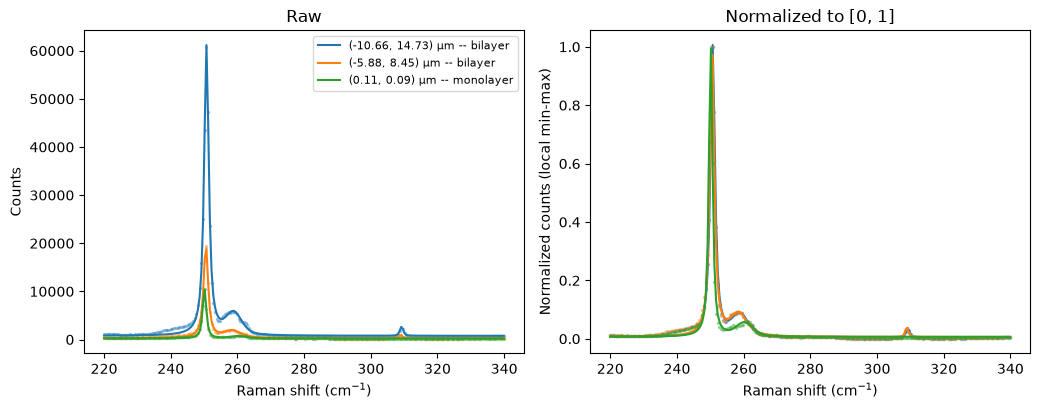

In [12]:
# Example: deep bilayer, a bilayer point near the boundary, deep monolayer.
POINTS = [(-10.66, 14.73), (-5.88, 8.45), (0.11, 0.09)]

overlay_results = {}
for x_req, y_req in POINTS:
    ix, iy = raman_map.nearest_index(x_req, y_req)
    x_actual, y_actual = raman_map.x[ix], raman_map.y[iy]
    layer = LAYER_NAMES[n_layers_map[iy, ix]]
    print(f"({x_req}, {y_req}) um -> nearest scan point ({x_actual:.2f}, {y_actual:.2f}) um, {layer}")
    overlay_results[f"({x_actual:.2f}, {y_actual:.2f}) µm -- {layer}"] = map_results[iy, ix]

plotting.plot_spectra_overlay(
    overlay_results, xlabel="Raman shift (cm$^{-1}$)",
    ylabel="Counts", ylabel_normalized="Normalized counts (local min-max)",
)

## How the fitted parameters vary across the chosen points

Reuses `plotting.plot_fit_param_comparison` (a library function, called earlier for the whole map's fits too) on the points selected above, all together in one call — E₂g/A₁g and 2LA(M) exist on every point regardless of layer, so they show all of them; B₂g exists only on the bilayer ones, so its panels show a gap at the monolayer point's position rather than omitting it from the axis or dropping it from the other panels too.

(<Figure size 1280x780 with 12 Axes>,
 array([[<Axes: title={'center': 'Center (cm$^{-1}$)'}, ylabel='E2g/A1g'>,
         <Axes: title={'center': 'Amplitude (counts)'}>,
         <Axes: title={'center': 'FWHM$_G$ (cm$^{-1}$)'}>,
         <Axes: title={'center': 'FWHM$_L$ (cm$^{-1}$)'}>],
        [<Axes: ylabel='2LA(M)'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='B2g'>, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

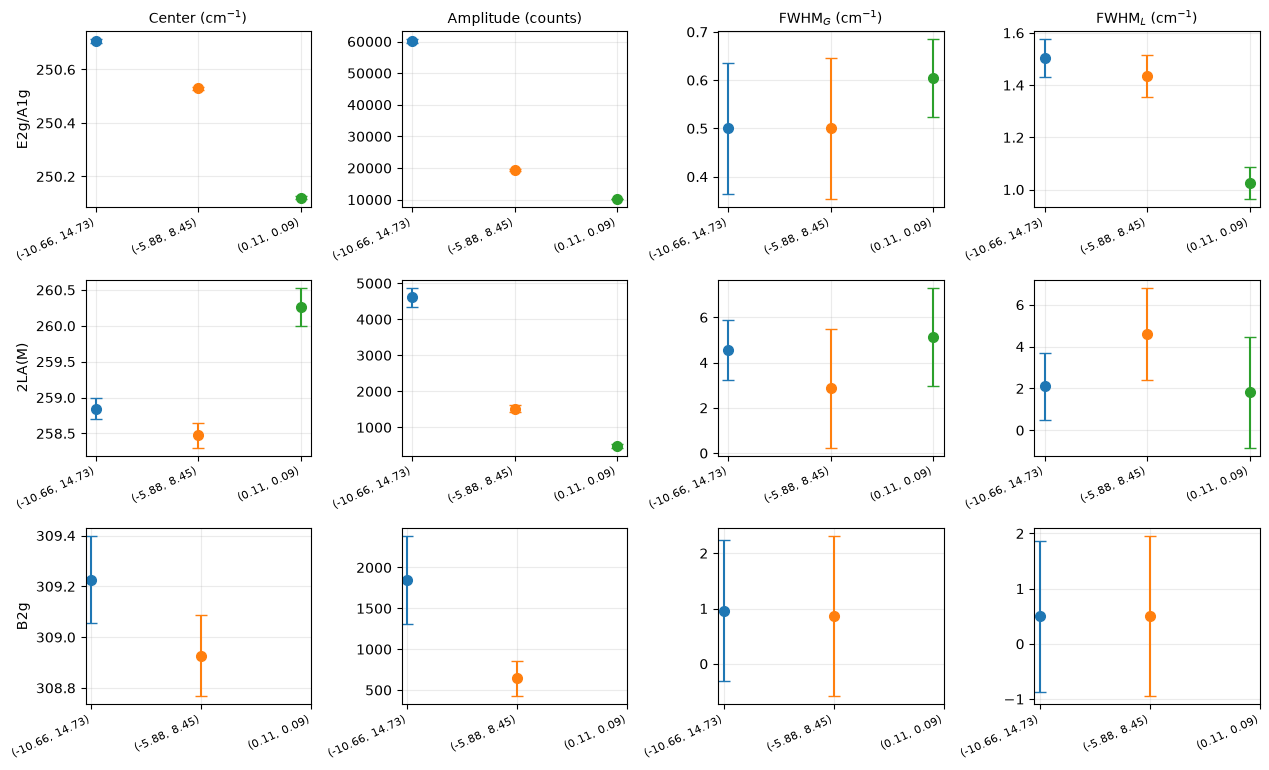

In [13]:
point_results = {}
for x_req, y_req in POINTS:
    ix, iy = raman_map.nearest_index(x_req, y_req)
    label = f"({raman_map.x[ix]:.2f}, {raman_map.y[iy]:.2f})"
    point_results[label] = map_results[iy, ix]

# BILAYER_MODES (3 modes) is a superset of MONOLAYER_MODES (2) -- any
# point without B2g simply leaves a gap in that panel; see
# plotting.plot_fit_param_comparison's docstring.
plotting.plot_fit_param_comparison(point_results, BILAYER_MODES, param_labels=RAMAN_PARAM_LABELS)